# 02 EDA

This notebook focuses on exploratory data analysis (EDA) for:
- `CurrentCigaretteUse`
- `HowTallAreYouWithoutShoesInMeters`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/YRBS_2007.csv')

def recode_smoking(x):
    if pd.isna(x):
        return pd.NA
    elif x in [2, 3, 4, 5, 6, 7]:
        return 1
    elif x == 1:
        return 0
    else:
        return pd.NA

smoke_raw = df['CurrentCigaretteUse']
df['CurrentCigaretteUse_Bin'] = df['CurrentCigaretteUse'].apply(recode_smoking)
smoke_bin = df['CurrentCigaretteUse_Bin'].dropna()
height = df['HowTallAreYouWithoutShoesInMeters'].dropna()

## EDA for the behavior variable

In [2]:
orig_freq = smoke_raw.value_counts(dropna=False).sort_index()
bin_freq = smoke_bin.value_counts().sort_index()
bin_prop = smoke_bin.value_counts(normalize=True).sort_index()

print('=== Original code frequencies ===')
display(orig_freq)

print('\n=== Binary frequencies ===')
display(bin_freq)

print('\n=== Binary proportions ===')
display(bin_prop)

=== Original code frequencies ===


CurrentCigaretteUse
1.0    10734
2.0      753
3.0      375
4.0      250
5.0      295
6.0      229
7.0      687
NaN      718
Name: count, dtype: int64


=== Binary frequencies ===


CurrentCigaretteUse_Bin
0    10734
1     2589
Name: count, dtype: int64


=== Binary proportions ===


CurrentCigaretteUse_Bin
0    0.805674
1    0.194326
Name: proportion, dtype: float64

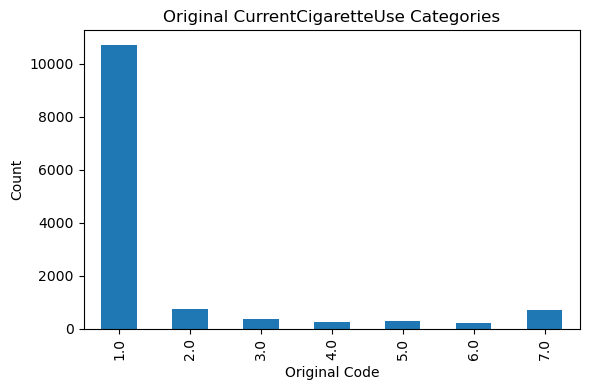

In [3]:
plt.figure(figsize=(6,4))
smoke_raw.value_counts().sort_index().plot(kind='bar')
plt.title('Original CurrentCigaretteUse Categories')
plt.xlabel('Original Code')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/current_cigarette_use_original_bar.png', dpi=300)
plt.show()

### Figure interpretation
- Code 1 is much more common than codes 2–7.
- This suggests that most students are in the non-smoking group before binary recoding.


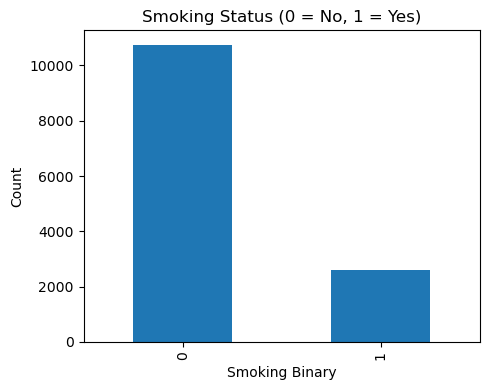

In [4]:
plt.figure(figsize=(5,4))
smoke_bin.value_counts().sort_index().plot(kind='bar')
plt.title('Smoking Status (0 = No, 1 = Yes)')
plt.xlabel('Smoking Binary')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/current_cigarette_use_binary_bar.png', dpi=300)
plt.show()

### Figure interpretation
- The number of non-smokers is much higher than the number of smokers.
- The smoking proportion appears to be around one-fifth of the sample, which is useful for the later proportion inference.


## EDA for the continuous variable

In [5]:
print('=== Height summary statistics ===')
display(height.describe())

height_summary = pd.DataFrame({
    'statistic': ['sample size','mean','median','std','min','Q1','Q3','max'],
    'value': [
        len(height),
        height.mean(),
        height.median(),
        height.std(ddof=1),
        height.min(),
        height.quantile(0.25),
        height.quantile(0.75),
        height.max()
    ]
})
height_summary.to_csv('../outputs/tables/height_eda_summary.csv', index=False)

=== Height summary statistics ===


count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64

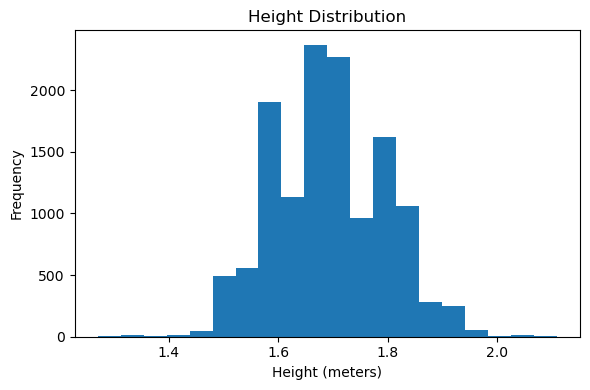

In [6]:
plt.figure(figsize=(6,4))
plt.hist(height, bins=20)
plt.title('Height Distribution')
plt.xlabel('Height (meters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/height_histogram.png', dpi=300)
plt.show()

### Figure interpretation
- Most heights are concentrated around 1.6 to 1.8 meters.
- The distribution looks roughly bell-shaped, so mean-based inference is reasonable.


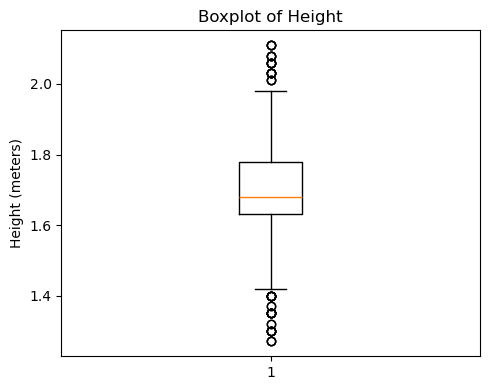

In [7]:
plt.figure(figsize=(5,4))
plt.boxplot(height, vert=True)
plt.title('Boxplot of Height')
plt.ylabel('Height (meters)')
plt.tight_layout()
plt.savefig('../outputs/figures/height_boxplot.png', dpi=300)
plt.show()

### Figure interpretation
- The median height is near the center of the distribution.
- A few outliers appear on both ends, but most values are concentrated in a moderate range.


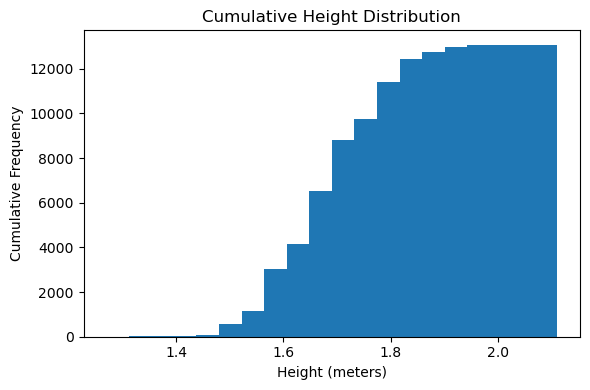

In [8]:
# Additional EDA required by the instructions
plt.figure(figsize=(6,4))
plt.hist(height, bins=20, cumulative=True)
plt.title('Cumulative Height Distribution')
plt.xlabel('Height (meters)')
plt.ylabel('Cumulative Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/height_cumulative_histogram.png', dpi=300)
plt.show()

### Additional EDA interpretation
- This additional EDA helps show how quickly the sample accumulates around the center.
- It supports the conclusion that most observations are concentrated near the average height.
